In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle("LabDelSole.pickle")

colori = sns.color_palette("pastel")

In [3]:
prezzo_tot = df["info"]["prezzo"].sum()
ore_tot = df["info"]["ore impiegate"].sum()
prezzo_ora_medio = prezzo_tot / ore_tot
prezzo_ora_medio

np.float64(8.666666666666666)

In [4]:
df_milk = pd.DataFrame()
df_milk["tipologia"] = df["info"]["tipologia"]
df_milk["ore"] = df["info"]["ore impiegate"]
df_milk["prezzo"] = df["info"]["prezzo"]
df_milk["quantita"] = df["passaparola"].sum(axis=1) + df["mercatino"].sum(axis=1) + df["info"]["rimaste"] + df["info"]["regalate"]
df_milk["totale ore"] = df_milk["ore"] * df_milk["quantita"]
df_milk["totale guadagno"] = df_milk["prezzo"] * df_milk["quantita"]
df_milk["prezzo ora"] = df_milk["totale guadagno"] / df_milk["totale ore"]
df_milk["conviene?"] = df_milk["prezzo ora"] > prezzo_ora_medio
df_milk.head()

,tipologia,ore,prezzo,quantita,totale ore,totale guadagno,prezzo ora,conviene?
0,ciondolo,8.0,50,4.0,32.0,200.0,6.250000,False
1,ciondolo,4.5,35,1.0,4.5,35.0,7.777778,False
2,orecchini,2.0,20,3.0,6.0,60.0,10.000000,True
3,orecchini,1.0,15,8.0,8.0,120.0,15.000000,True
4,orecchini,1.5,15,3.0,4.5,45.0,10.000000,True


In [5]:
df_quantita = df_milk.groupby(["prezzo", "ore"], as_index=False).agg({
    "quantita": "sum",
    "conviene?": "first" #tanto sono tutti uguali
})
df_quantita

,prezzo,ore,quantita,conviene?
0,5,0.5,1.0,True
1,10,1.0,3.0,True
2,15,1.0,22.0,True
3,15,1.5,14.0,True
4,20,1.0,10.0,True
5,20,1.5,5.0,True
6,20,2.0,25.0,True
7,20,2.5,3.0,False
8,20,3.0,2.0,False
9,20,3.5,1.0,False


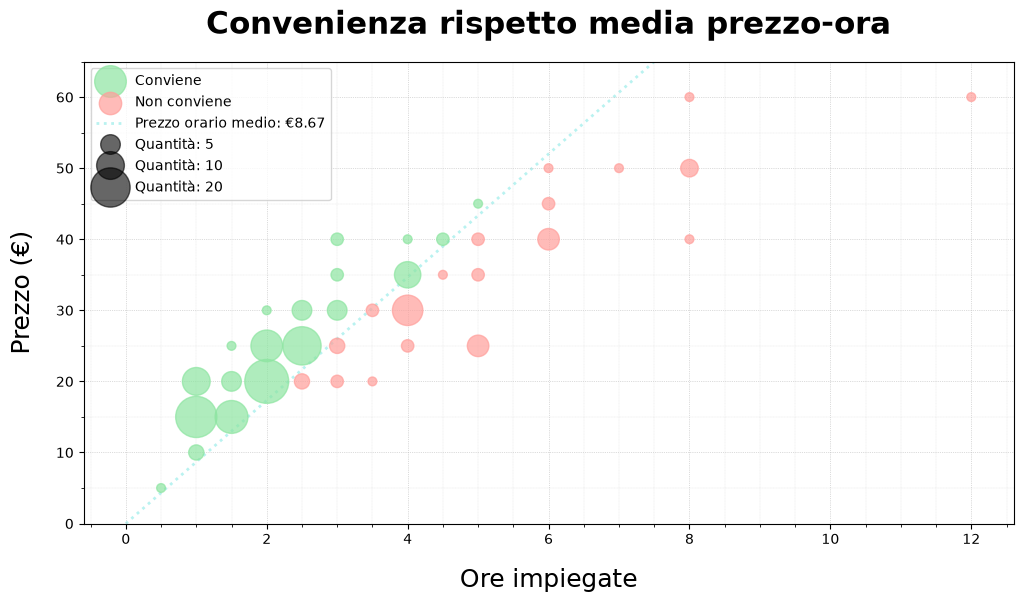

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

mask = df_quantita["conviene?"]
g = 40

sc1 = ax.scatter(
    df_quantita.loc[mask, "ore"],
    df_quantita.loc[mask, "prezzo"],
    s=df_quantita.loc[mask, "quantita"] * g,
    color=colori[2], 
    alpha=0.7, 
    label="Conviene",
    zorder=2
)

ax.scatter(
    df_quantita.loc[~mask, "ore"], 
    df_quantita.loc[~mask, "prezzo"],
    s=df_quantita.loc[~mask, "quantita"] * g,
    color=colori[3], 
    alpha=0.7, 
    label="Non conviene",
    zorder=2
)

#media = df_info["ore impiegate"].mean()
ax.axline(
    (0,0),
    slope=prezzo_ora_medio,
    linestyle=":",
    linewidth=2,
    color=colori[9],
    label="Prezzo orario medio: " + f"€{prezzo_ora_medio:.2f}",
    zorder=1
)

ax.set_facecolor("#FFFFFF")
ax.grid(True, color="#BBBBBB", linewidth=0.5, linestyle=":")
ax.grid(True, axis='y', which='minor', linewidth=0.2, linestyle=":")
ax.grid(True, axis='x', which='minor', linewidth=0.2, linestyle=":")
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax.xaxis.set_major_locator(plt.MultipleLocator(2))
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.set_ylim(0, 65)

ax.set_title("Convenienza rispetto media prezzo-ora", pad=20, fontsize=22, fontweight="bold")
ax.set_xlabel("Ore impiegate", fontsize=18, fontweight="normal", labelpad=15)
ax.set_ylabel("Prezzo (€)", fontsize=18, fontweight="normal", labelpad=15)

handles, labels = ax.get_legend_handles_labels()

size_handles, size_labels = sc1.legend_elements(
    prop="sizes", alpha=0.6, num=[5, 10, 20], func=lambda s: s / g, fmt="Quantità: {x:.0f}"
)
ax.legend(handles=handles + size_handles, labels=labels + size_labels, loc="best")

plt.savefig("Media-prezzo-ora.svg", bbox_inches="tight", pad_inches=0.3, transparent=False)
plt.savefig("Media-prezzo-ora.png", bbox_inches="tight", pad_inches=0.3, transparent=False)
